In [16]:
import ssl
import certifi
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())


import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [17]:
list(train_dataset.as_numpy_iterator())[0]

2026-04-05 18:32:11.412111: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[[209.      , 208.      , 214.      ],
          [209.00447 , 208.00893 , 214.00447 ],
          [209.6741  , 209.34822 , 214.6741  ],
          ...,
          [212.3259  , 213.33705 , 221.      ],
          [212.99554 , 213.00223 , 221.      ],
          [213.      , 213.      , 221.      ]],
 
         [[209.01785 , 208.02232 , 213.93973 ],
          [209.02228 , 208.03119 , 213.94415 ],
          [209.6852  , 209.36226 , 214.60631 ],
          ...,
          [212.3043  , 213.31992 , 220.88092 ],
          [212.97545 , 212.98659 , 220.88391 ],
          [212.9799  , 212.98438 , 220.88393 ]],
 
         [[211.69643 , 211.37053 , 204.89955 ],
          [211.69412 , 211.37119 , 204.8965  ],
          [211.34808 , 211.4691  , 204.4376  ],
          ...,
          [209.0652  , 210.75047 , 203.0188  ],
          [209.96056 , 210.64136 , 203.47021 ],
          [209.96652 , 210.64062 , 203.4732  ]],
 
         ...,
 
         [[113.44374 , 115.11784 , 117.08438 ],
          [113.443

In [18]:
class_names = train_dataset.class_names
class_names

['cat', 'dog']

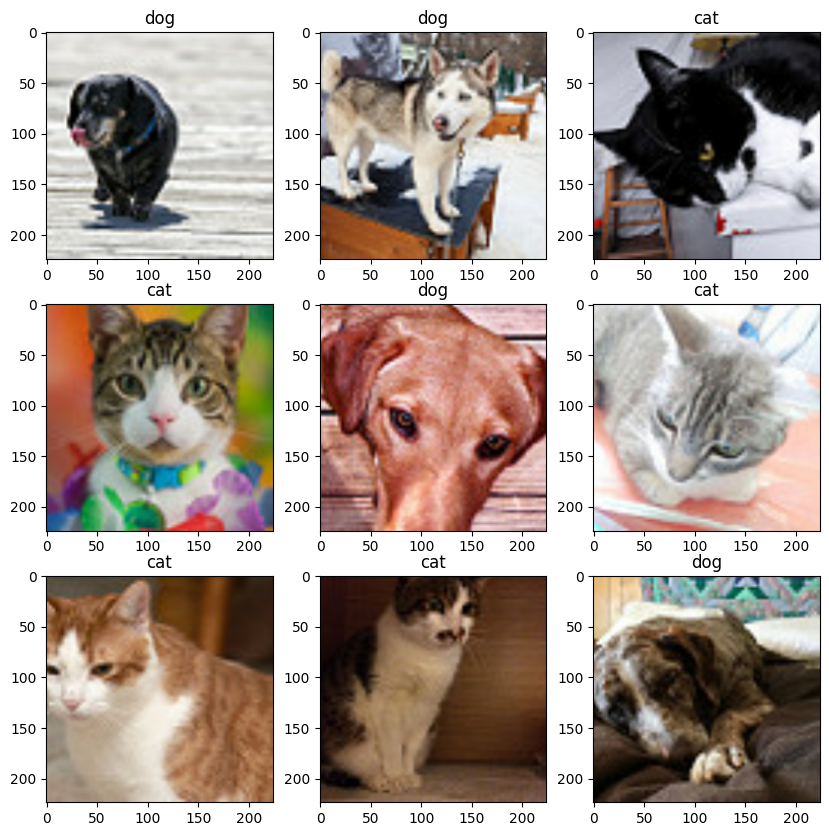

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [20]:
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label


In [21]:
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [22]:
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [23]:
train_dataset = train_dataset.shuffle(32)

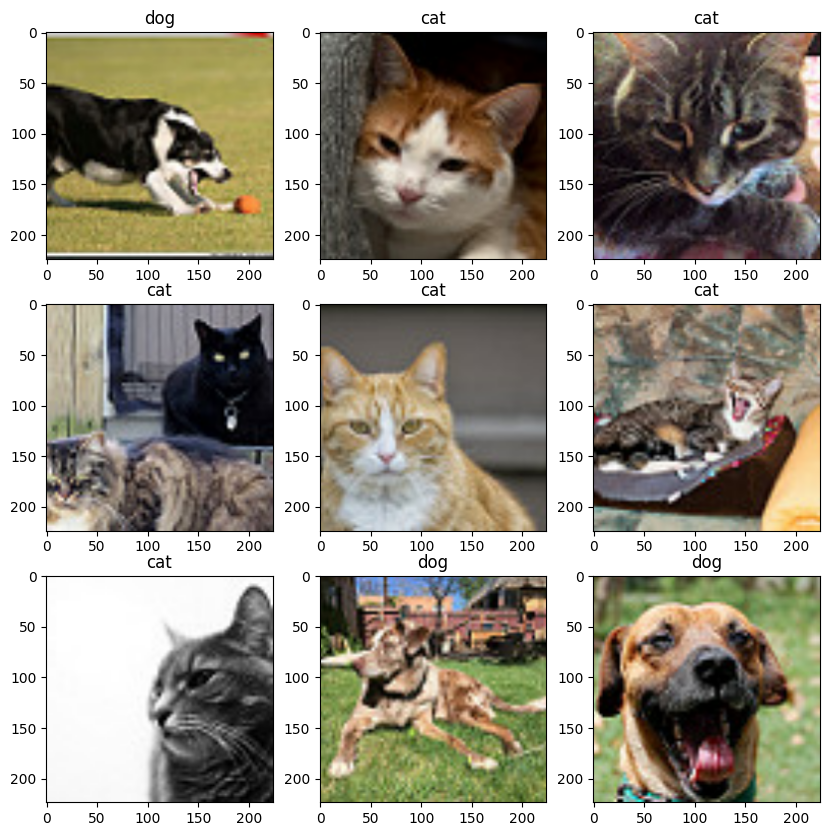

In [24]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [26]:
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights=None,
    pooling='avg'
)
base_model.trainable = False


In [27]:
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [28]:
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [29]:
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [30]:
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 196ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.4800 - loss: 0.6932
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.4833 - loss: 0.6932
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.4989 - loss: 0.6932
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 202ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.5000 - loss: 0.6932
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11

In [31]:
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step


In [32]:
pred_data

array([[0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.49920782],
       [0.499

In [33]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5000 - loss: 0.6931


[0.6931484341621399, 0.5]